<a href="https://colab.research.google.com/github/rongxie2023/dlcv/blob/main/Chapter03/16-case1-mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torch import optim  # For optimizers like SGD, Adam, etc.
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import numpy as np

import torchvision.datasets as datasets  # Standard datasets
import torchvision.transforms as transforms  # Transformations we can perform on our dataset for augmentation
from torchmetrics import Accuracy, Recall, AUROC, ROC
# from sklearn.metrics import accuracy_score, recall_score

In [3]:
# 超参数 Hyperparameters
input_size = 784    # 28*28
num_classes = 10    # 10个类别
learning_rate = 0.001
batch_size = 64
num_epochs = 3

# Load Data
train_dataset = datasets.MNIST(root="../datasets/", train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root="../datasets/", train=False, transform=transforms.ToTensor(), download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

# Set device cuda for GPU if it's available otherwise run on the CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# 初始化网络
net = nn.Sequential(
    nn.Flatten(), 
    nn.Linear(input_size, num_classes)
)

model = net.to(device)
# Loss and optimizer
criterion = nn.CrossEntropyLoss() #交叉熵损失用来计算预测概率分布与真实标签之间的差异
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


cuda


In [4]:
# Train Network

# 使用TensorBoard记录训练过程
writer = SummaryWriter()

for epoch in range(num_epochs):
    for batch_idx, (data, targets) in enumerate(tqdm(train_loader)):
        # Get data to cuda if possible
        data = data.to(device=device)
        targets = targets.to(device=device)

        # Get to correct shape
        # data = data.reshape(data.shape[0], -1)

        # Forward
        scores = model(data)
        loss = criterion(scores, targets)
        # 使用TensorBoard记录损失
        writer.add_scalar('Loss', loss.item(), epoch)


        # Backward
        optimizer.zero_grad()
        loss.backward()

        # Gradient descent or adam step
        optimizer.step()


### 命令行输入：tensorboard --logdir runs


100%|██████████| 938/938 [00:09<00:00, 103.54it/s]


In [5]:
def test_results(loader, model, device):
    all_preds = []
    all_targets = []
    all_probs = []


    model.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device)
            y = y.to(device=device)
            # x = x.reshape(x.shape[0], -1)
            
            output  = model(x)
            _, predictions = output .max(1)
            probs = torch.softmax(output, dim=1)
            
            all_preds.extend(predictions.cpu())
            all_targets.extend(y.cpu())
            all_probs.append(probs.cpu())

    # 合并所有预测值和真实值
    all_preds = torch.stack(all_preds)
    all_targets = torch.stack(all_targets)
    all_probs = torch.cat(all_probs,dim=0)
    model.train()
    return all_preds,all_targets,all_probs

# preds,targets,probs=test_results(train_loader, model, device)
preds,targets,probs=test_results(test_loader, model, device)

Accuracy & Recall & ROC on test set: 92.22  92.10 99.38


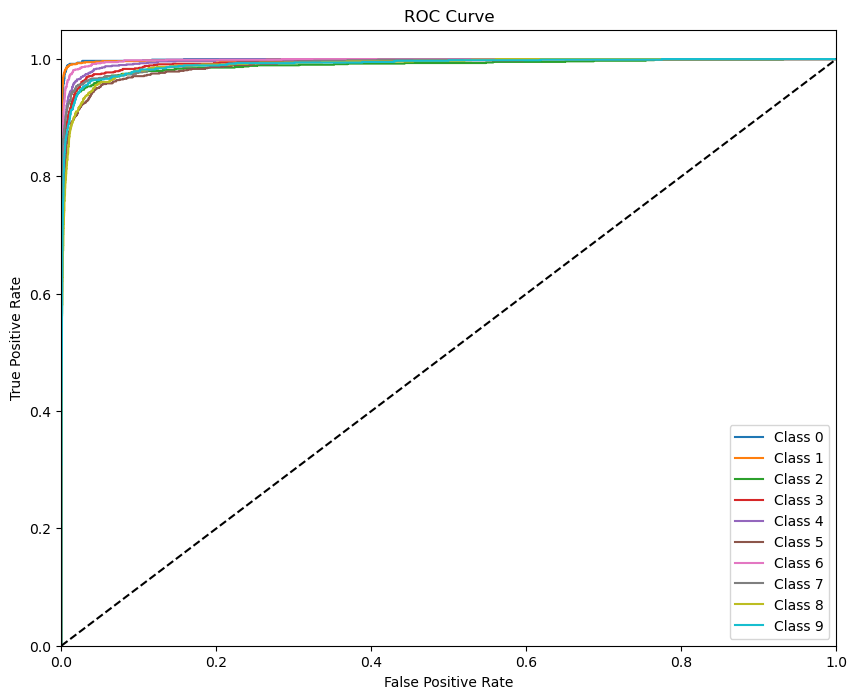

In [6]:
# 计算准确率和召回率
# accuracy = accuracy_score(all_targets, all_preds)
# recall = recall_score(all_targets, all_preds, average='macro')
accuracy = Accuracy(task="multiclass", num_classes=num_classes)(preds, targets)
recall = Recall(task="multiclass", num_classes=num_classes, average='macro')(preds, targets)

# 计算AUC
auroc = AUROC(task="multiclass", num_classes=num_classes)
auc = auroc(probs, targets)
print(f"Accuracy & Recall & ROC on test set: {accuracy*100:.2f}  {recall*100:.2f} {auc*100:.2f}")

# 计算并绘制ROC曲线
roc = ROC(task="multiclass", num_classes=10)
fpr, tpr, _ = roc(probs, targets)


import matplotlib.pyplot as plt
# 绘制ROC曲线
plt.figure(figsize=(10, 8))
for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f'Class {i}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [7]:
# 手动计算准确率和召回率

# 计算准确率
correct = (preds == targets).sum().item()
total = targets.size(0)
accuracy = correct / total

# 计算召回率
# 解释
# all_targets[all_preds != all_targets] 提取所有错误预测的实际标签。
# torch.bincount 统计每个类别在错误预测中的出现次数

tp = torch.bincount(targets[preds == targets], minlength=num_classes).float()
fn = torch.bincount(targets[preds != targets], minlength=num_classes).float()
recall=tp/(tp+fn)
recall=recall.mean()

print(f"Accuracy & Recall on test set: {accuracy*100:.2f}  {recall*100:.2f}")



Accuracy & Recall on test set: 92.22  92.10


torch.Size([1, 28, 28]) 5


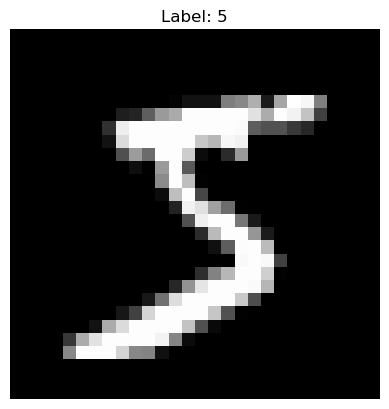

In [8]:
import matplotlib.pyplot as plt

# 2. 选择一个样本
idx = 0  # 选择第几个样本
sample = train_dataset[idx]

# 获取图像数据和标签
image, label = sample
print(image.shape,label)

# 3. 显示图像
plt.imshow(image.squeeze().numpy(), cmap='gray')  # 将图像数据转换为numpy数组并显示,squeeze()去掉一个通道
plt.title(f"Label: {label}")
plt.axis('off')  # 关闭坐标轴
plt.show()